# Candlestick Data Visualization

Interactive candlestick charts using Plotly for trading data analysis.

## Import Libraries

In [4]:
import json
import os
import sys
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Add parent directory to path for imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

## Load Candlestick Data

Load data from JSON file. The file should contain OHLCV data in the format:
```json
[
  {"Date": "2020-01-01 17:00:00+0000", "Open": 1.12, "High": 1.13, "Low": 1.11, "Close": 1.12, "Volume": 0.0}
]
```

In [5]:
def load_candle_data(filename):
    """Load candlestick data from JSON file."""
    filepath = Path('../data') / filename
    
    if not filepath.exists():
        raise FileNotFoundError(f"File not found: {filepath}")
    
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    df['Date'] = pd.to_datetime(df['Date'], utc=True)
    df = df.sort_values('Date')
    
    print(f"Loaded {len(df)} candles from {filename}")
    print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
    print(f"Columns: {list(df.columns)}")
    
    return df

In [6]:
# List available data files
data_dir = Path('../data')
json_files = sorted([f.name for f in data_dir.glob('*.json')])

print("Available data files:")
for i, f in enumerate(json_files, 1):
    print(f"  {i}. {f}")

Available data files:
  1. candle_data_list_frxEURUSD_300s.json
  2. candle_data_list_frxEURUSD_3600s.json
  3. candle_data_list_frxEURUSD_900s.json


In [7]:
# Load your data file (change filename as needed)
filename = 'candle_data_list_frxEURUSD_300s.json'  # 5-minute data

df = load_candle_data(filename)
df.head()

Loaded 62518 candles from candle_data_list_frxEURUSD_300s.json
Date range: 2025-01-01 17:00:00+00:00 to 2025-10-31 16:00:00+00:00
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


,Date,Open,High,Low,Close,Volume
0,2025-01-01 17:00:00+00:00,1.03503,1.03514,1.03503,1.03514,0.0
1,2025-01-01 17:05:00+00:00,1.03514,1.03519,1.03507,1.03515,0.0
2,2025-01-01 17:10:00+00:00,1.03516,1.03516,1.03484,1.03501,0.0
3,2025-01-01 17:15:00+00:00,1.03501,1.03504,1.03483,1.03501,0.0
4,2025-01-01 17:20:00+00:00,1.03502,1.03532,1.03500,1.03530,0.0


## Plot Candlestick Chart

Create an interactive candlestick chart with volume subplot.

In [8]:
def plot_candlestick(df, title=None, show_volume=True, height=800):
    """
    Create interactive candlestick chart with optional volume subplot.
    
    Args:
        df: DataFrame with columns Date, Open, High, Low, Close, Volume
        title: Chart title (auto-generated if None)
        show_volume: Whether to show volume subplot
        height: Chart height in pixels
    """
    if title is None:
        symbol = "Unknown"
        date_range = f"{df['Date'].min().date()} to {df['Date'].max().date()}"
        title = f"Candlestick Chart - {len(df)} candles ({date_range})"
    
    # Create subplots
    if show_volume:
        fig = make_subplots(
            rows=2, cols=1,
            shared_xaxes=True,
            vertical_spacing=0.03,
            row_heights=[0.7, 0.3],
            subplot_titles=(title, 'Volume')
        )
    else:
        fig = go.Figure()
    
    # Add candlestick chart
    candlestick = go.Candlestick(
        x=df['Date'],
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
        name='OHLC',
        increasing_line_color='green',
        decreasing_line_color='red'
    )
    
    if show_volume:
        fig.add_trace(candlestick, row=1, col=1)
        
        # Add volume bars
        colors = ['green' if close >= open else 'red' 
                  for close, open in zip(df['Close'], df['Open'])]
        
        volume = go.Bar(
            x=df['Date'],
            y=df['Volume'],
            name='Volume',
            marker_color=colors,
            showlegend=False
        )
        fig.add_trace(volume, row=2, col=1)
    else:
        fig.add_trace(candlestick)
        fig.update_layout(title=title)
    
    # Update layout
    fig.update_layout(
        height=height,
        xaxis_rangeslider_visible=False,
        hovermode='x unified',
        template='plotly_white'
    )
    
    # Update axes
    fig.update_xaxes(title_text="Date", row=2 if show_volume else 1, col=1)
    fig.update_yaxes(title_text="Price", row=1, col=1)
    if show_volume:
        fig.update_yaxes(title_text="Volume", row=2, col=1)
    
    return fig

In [ ]:
# Plot the candlestick chart
fig = plot_candlestick(df, show_volume=True)
fig.show()

## Plot Subset of Data

Zoom in on a specific date range for detailed analysis.

In [ ]:
# Filter to specific date range
start_date = df['Date'].min()
end_date = start_date + pd.Timedelta(hours=12)  # First 12 hours

df_subset = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

print(f"Subset: {len(df_subset)} candles from {start_date} to {end_date}")

fig_subset = plot_candlestick(df_subset, title=f"Candlestick Chart (First 12 hours)", show_volume=True)
fig_subset.show()

## Add Technical Indicators (Optional)

Add simple moving averages to the candlestick chart.

In [10]:
def plot_candlestick_with_ma(df, ma_periods=[20, 50], title=None, height=800):
    """
    Create candlestick chart with moving averages.
    
    Args:
        df: DataFrame with OHLCV data
        ma_periods: List of moving average periods
        title: Chart title
        height: Chart height in pixels
    """
    if title is None:
        title = f"Candlestick Chart with Moving Averages"
    
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.03,
        row_heights=[0.7, 0.3],
        subplot_titles=(title, 'Volume')
    )
    
    # Add candlestick
    fig.add_trace(
        go.Candlestick(
            x=df['Date'],
            open=df['Open'],
            high=df['High'],
            low=df['Low'],
            close=df['Close'],
            name='OHLC',
            increasing_line_color='green',
            decreasing_line_color='red'
        ),
        row=1, col=1
    )
    
    # Add moving averages
    colors = ['blue', 'orange', 'purple', 'brown']
    for i, period in enumerate(ma_periods):
        ma = df['Close'].rolling(window=period).mean()
        fig.add_trace(
            go.Scatter(
                x=df['Date'],
                y=ma,
                name=f'MA{period}',
                line=dict(color=colors[i % len(colors)], width=1.5)
            ),
            row=1, col=1
        )
    
    # Add volume
    colors = ['green' if close >= open else 'red' 
              for close, open in zip(df['Close'], df['Open'])]
    
    fig.add_trace(
        go.Bar(
            x=df['Date'],
            y=df['Volume'],
            name='Volume',
            marker_color=colors,
            showlegend=False
        ),
        row=2, col=1
    )
    
    # Update layout
    fig.update_layout(
        height=height,
        xaxis_rangeslider_visible=False,
        hovermode='x unified',
        template='plotly_white'
    )
    
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="Volume", row=2, col=1)
    
    return fig

In [ ]:
# Plot with moving averages
fig_ma = plot_candlestick_with_ma(df, ma_periods=[20, 50], title="Candlestick with MA20 and MA50")
fig_ma.show()

## Compare Multiple Timeframes

Load and compare data at different timeframes.

In [17]:
# Example: Load both 5m and 1h data if available
# Uncomment and adjust filenames as needed

# df_5m = load_candle_data('candle_data_list_frxEURUSD_300s.json')
# df_1h = load_candle_data('candle_data_list_frxEURUSD_3600s.json')

# fig_5m = plot_candlestick(df_5m, title="5-Minute Chart", height=400)
# fig_1h = plot_candlestick(df_1h, title="1-Hour Chart", height=400)

# fig_5m.show()
# fig_1h.show()

## Plot trades

Plot a recent backtest onto the candle data

In [ ]:
# Same candlestick chart as before but with trade data

# Configure the path to the backtest results JSON
from pathlib import Path
import json
import pandas as pd
import plotly.graph_objects as go

results_path = Path("../results/keltner_squeeze_breakout/evaluations/full_dataset_backtest.json")

with open(results_path, "r") as f:
    eval_payload = json.load(f)

trades_raw = eval_payload.get("trades_detail", [])

# If no trades found, bail out gracefully
if not trades_raw:
    print("No trades_detail found in the results JSON.")
else:
    trades_df = pd.DataFrame(trades_raw)

    # Parse times to timezone-aware datetimes (backtester writes ISO timestamps in UTC)
    for col in ("entry_time", "exit_time"):
        if col in trades_df.columns:
            trades_df[col] = pd.to_datetime(trades_df[col], utc=True, errors="coerce")

    # Choose which candle DataFrame window you want to overlay on:
    # - For full chart use df
    # - For a zoomed chart use df_subset (if created in a previous cell)
    candles_window = df  # or df_subset

    # Filter trades to the visible candle window for clarity
    window_start = candles_window["Date"].min()
    window_end = candles_window["Date"].max()
    trades_vis = trades_df[(trades_df["entry_time"] >= window_start) & (trades_df["entry_time"] <= window_end)].copy()

    # Optional: cap number of plotted trades to keep the figure responsive
    MAX_TRADES = 800000
    if len(trades_vis) > MAX_TRADES:
        trades_vis = trades_vis.tail(MAX_TRADES)

    # Split by side for coloring/markers
    buys = trades_vis[trades_vis["direction"] == "BUY"].copy()
    sells = trades_vis[trades_vis["direction"] == "SELL"].copy()

    # Helper to add entry markers
    def add_entry_markers(fig_obj, df_side, side_name, color, marker_symbol):
        if df_side.empty:
            return
        hoverdata = pd.DataFrame({
            "Side": df_side["direction"],
            "Size": df_side.get("size", pd.Series([None]*len(df_side))),
            "SL": df_side.get("stop_price", pd.Series([None]*len(df_side))),
            "TP": df_side.get("take_profit_price", pd.Series([None]*len(df_side))),
        })
        fig_obj.add_trace(go.Scatter(
            x=df_side["entry_time"],
            y=df_side["entry_price"],
            mode="markers",
            name=f"{side_name} Entry",
            marker=dict(color=color, symbol=marker_symbol, size=9, line=dict(color="black", width=0.5)),
            customdata=hoverdata[["Side", "Size", "SL", "TP"]].to_numpy(),
            hovertemplate="<b>%{customdata[0]}</b><br>"
                          "Entry: %{y:.5f}<br>"
                          "Size: %{customdata[1]:.2f}<br>"
                          "SL: %{customdata[2]:.5f}<br>"
                          "TP: %{customdata[3]:.5f}<br>"
                          "Time: %{x|%Y-%m-%d %H:%M:%S %Z}<extra></extra>",
            showlegend=True
        ))

    # Helper to add exit markers
    def add_exit_markers(fig_obj, df_side, side_name, color):
        df_side = df_side.dropna(subset=["exit_time", "exit_price"])
        if df_side.empty:
            return
        hoverdata = pd.DataFrame({
            "PnL": df_side.get("pnl", pd.Series([None]*len(df_side))),
            "ExitPx": df_side["exit_price"],
        })
        fig_obj.add_trace(go.Scatter(
            x=df_side["exit_time"],
            y=df_side["exit_price"],
            mode="markers",
            name=f"{side_name} Exit",
            marker=dict(color=color, symbol="x", size=8, line=dict(color="black", width=0.5), opacity=0.85),
            customdata=hoverdata[["PnL", "ExitPx"]].to_numpy(),
            hovertemplate="<b>Exit</b><br>"
                          "Exit: %{customdata[1]:.5f}<br>"
                          "PnL: %{customdata[0]:.2f}<br>"
                          "Time: %{x|%Y-%m-%d %H:%M:%S %Z}<extra></extra>",
            showlegend=True
        ))

    # Helper to draw entry->exit lines (optional)
    def add_entry_exit_lines(fig_obj, df_side, color, opacity=0.35, width=1.5):
        df_side = df_side.dropna(subset=["exit_time", "exit_price"])
        if df_side.empty:
            return
        # One trace per trade keeps hover clean but can be heavy for thousands of trades.
        # For performance, you could aggregate by batching, but this keeps it simple/readable.
        for _, r in df_side.iterrows():
            fig_obj.add_trace(go.Scatter(
                x=[r["entry_time"], r["exit_time"]],
                y=[r["entry_price"], r["exit_price"]],
                mode="lines",
                line=dict(color=color, width=width),
                opacity=opacity,
                hoverinfo="skip",
                showlegend=False
            ))

    # Pick the figure to overlay on (fig for full, or fig_subset for zoomed)
    target_fig = fig  # or fig_subset

    # Add overlays
    add_entry_markers(target_fig, buys, "Buy", color="seagreen", marker_symbol="triangle-up")
    add_entry_markers(target_fig, sells, "Sell", color="crimson", marker_symbol="triangle-down")
    add_exit_markers(target_fig, buys, "Buy", color="darkgreen")
    add_exit_markers(target_fig, sells, "Sell", color="darkred")

    # Toggle to draw lines between entry and exit
    SHOW_LINES = True
    if SHOW_LINES:
        add_entry_exit_lines(target_fig, buys, color="seagreen", opacity=0.30, width=1.2)
        add_entry_exit_lines(target_fig, sells, color="crimson", opacity=0.30, width=1.2)

    # Optional: tighten the y-range around visible data
    # target_fig.update_yaxes(range=[candles_window["Low"].min(), candles_window["High"].max()])

    target_fig.show()

## Export Chart to HTML

Save the interactive chart as an HTML file for sharing.

In [ ]:
# Save chart to HTML file
output_dir = Path('../scripts/outputs')
output_dir.mkdir(exist_ok=True)

output_file = output_dir / 'candlestick_chart.html'
fig.write_html(str(output_file))

print(f"Chart saved to: {output_file}")

../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l100_r1_ls0.json


/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/1508624278.py:81: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



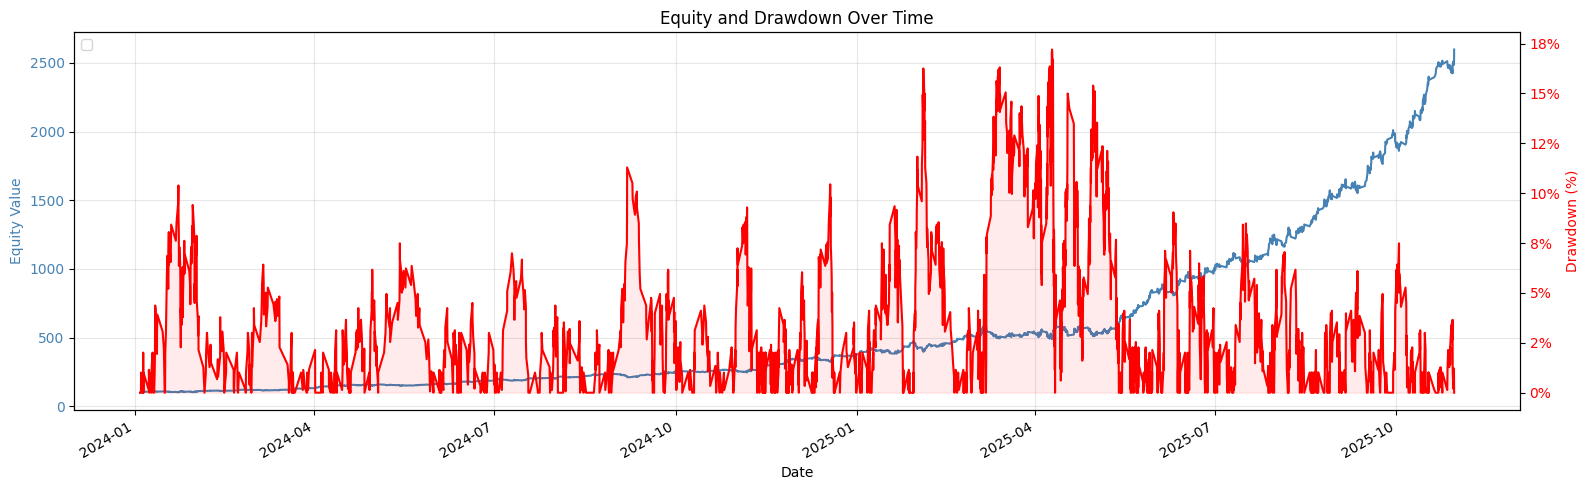

/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/1508624278.py:81: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l100_r1_ls1.json


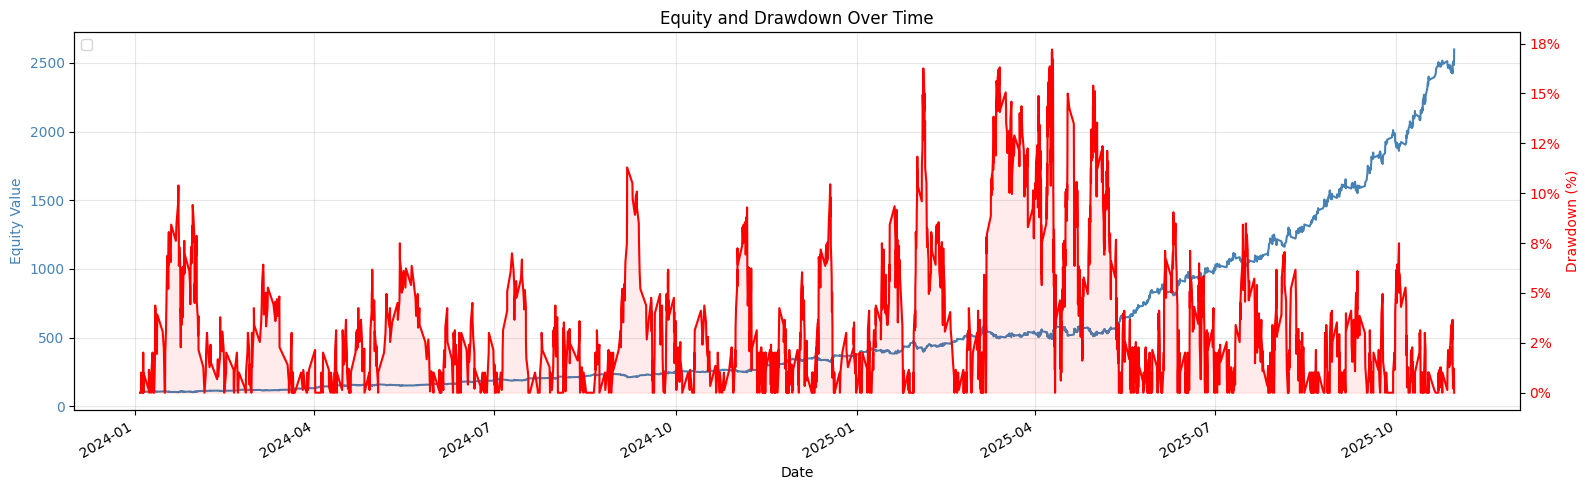

/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/1508624278.py:81: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l200_r1_ls1.json


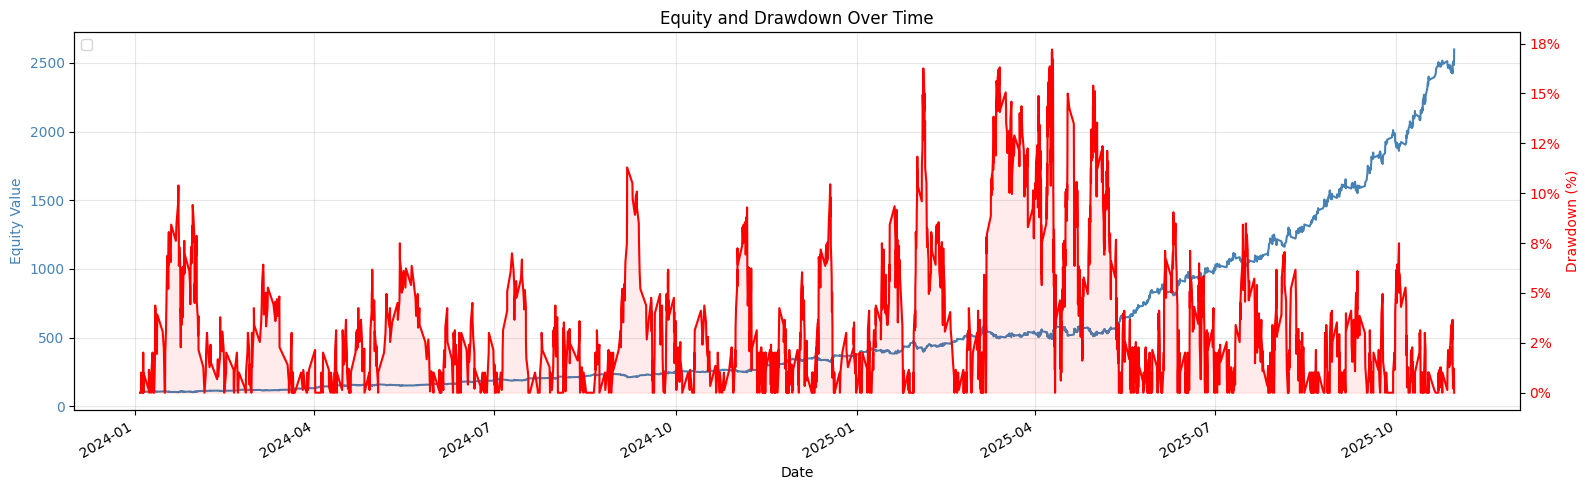

/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/1508624278.py:81: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l200_r2_ls1.json


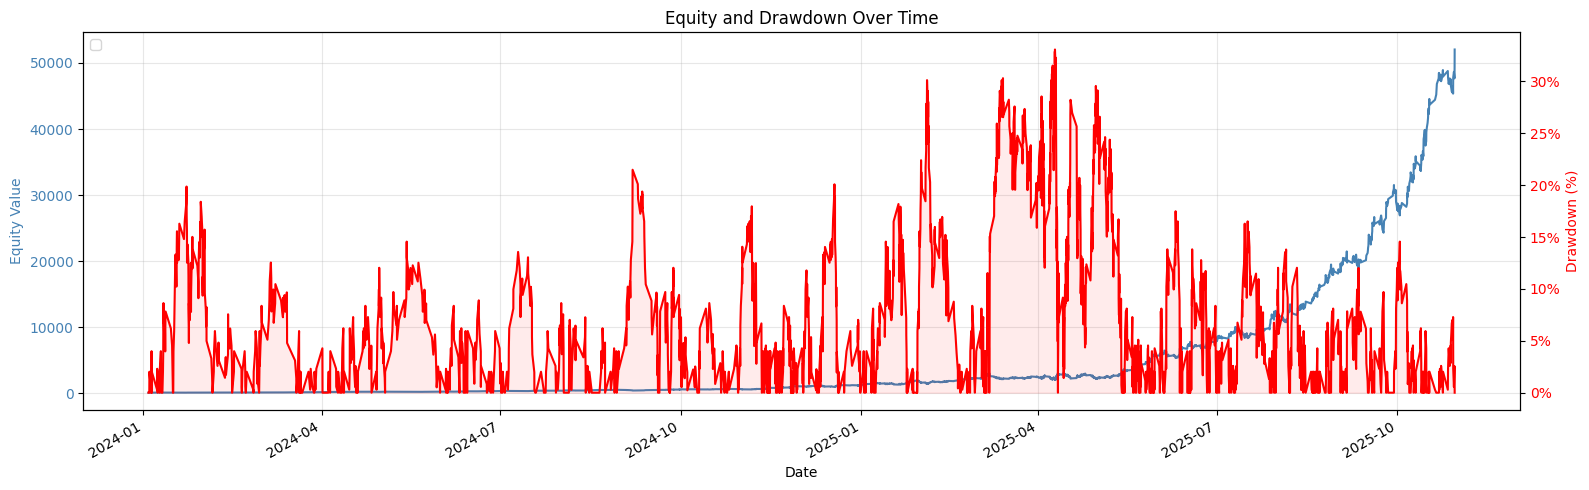

../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l100_r3_ls1.json


/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/1508624278.py:81: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



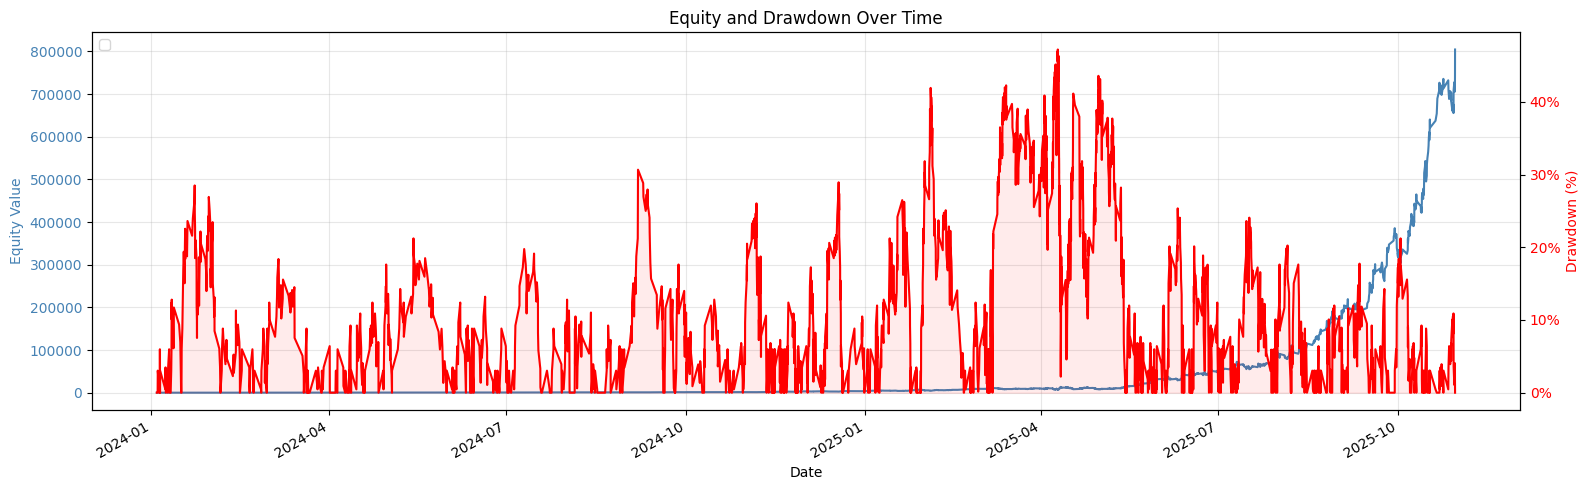

../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l100_r5_ls1.json


/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/1508624278.py:81: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



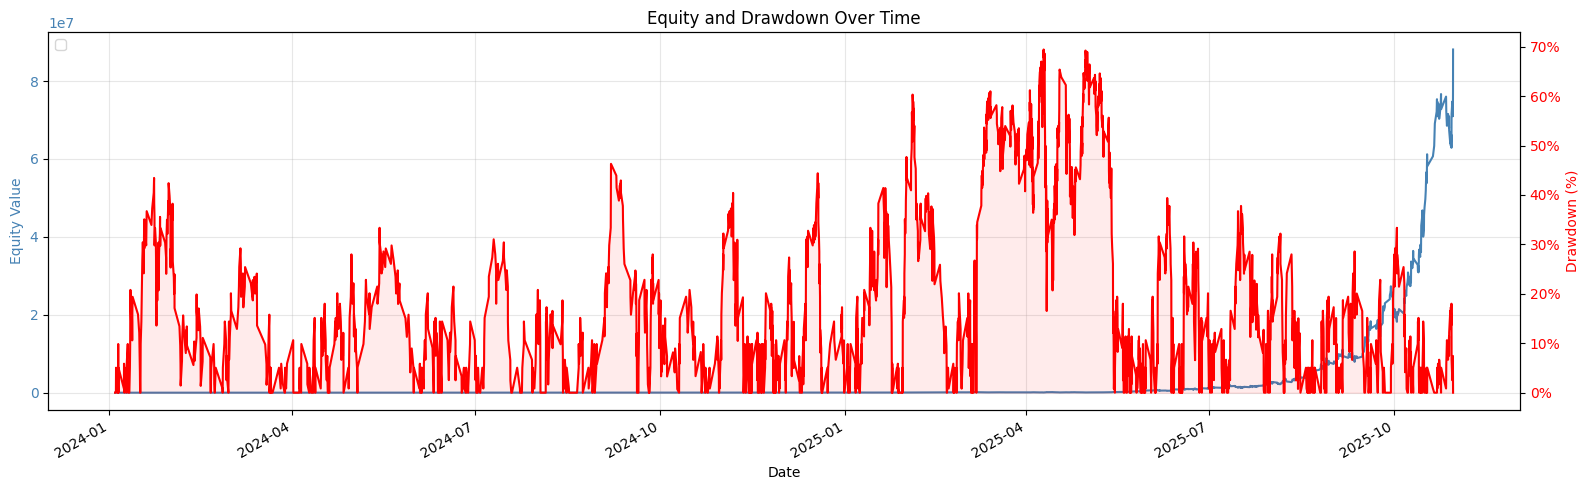

../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l200_r5_ls1.json


/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/1508624278.py:81: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



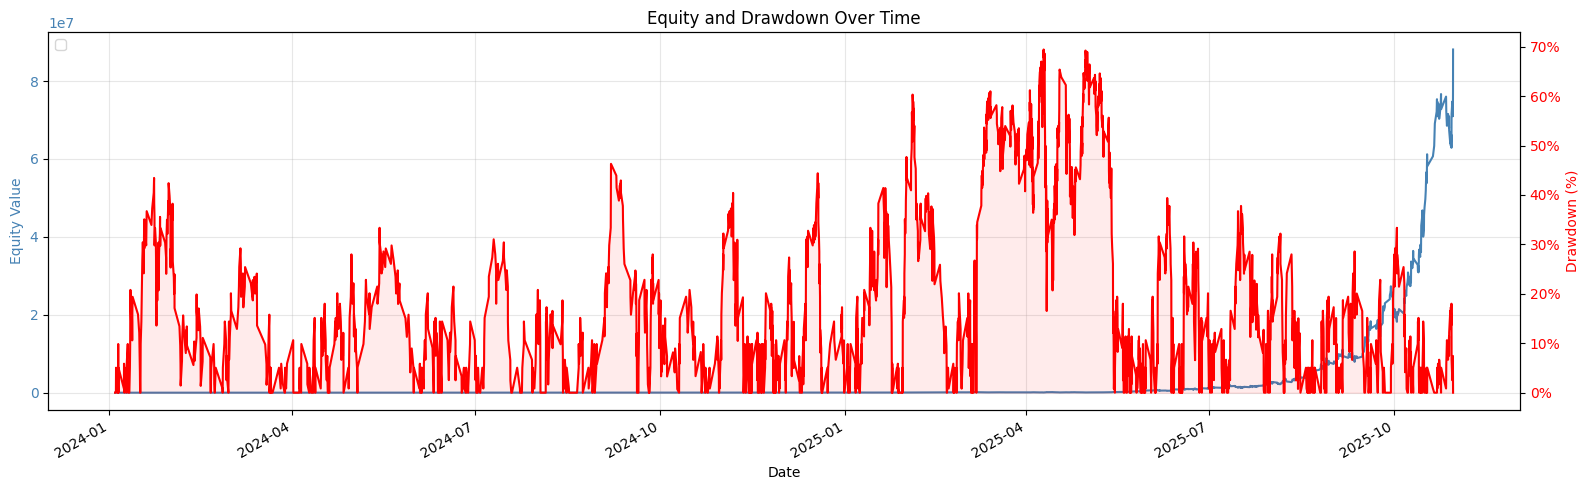

In [71]:
# Plot drawdown/equity curve from trades_detail
from pathlib import Path
import json
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

results_paths = [Path("../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l100_r1_ls0.json"),
Path("../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l100_r1_ls1.json"),
Path("../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l200_r1_ls1.json"),
Path("../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l200_r2_ls1.json"),
Path("../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l100_r3_ls1.json"),
Path("../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l100_r5_ls1.json"),
Path("../results_2025-11-13/keltner_squeeze_breakout/evaluations/full_dataset_backtest_b100_l200_r5_ls1.json")]

for results_path in results_paths:
    print(results_path)
    with open(results_path, "r") as f:
        eval_payload = json.load(f)

    equity = [100]
    last_high = 100
    drop_from_previous_high = [0]
    drop_from_previous_high_perc = [0]
    date_times = ["2024-01-03T19:15:00+00:00"]
    for ii in eval_payload['trades_detail']:
        date_times.append(ii['exit_time'])
        equity.append(equity[-1] + ii['pnl'])
        last_high = max(last_high, equity[-1])
        
        drop_from_previous_high.append(last_high - equity[-1])
        drop_from_previous_high_perc.append((last_high - equity[-1]) / last_high * 100)
        
    equity_data = pd.DataFrame({
        "Date": pd.to_datetime(date_times, utc=True),
        "Equity": equity,
        "Drawdown": drop_from_previous_high,
        "DrawdownPerc": drop_from_previous_high_perc
    })

    equity_data.set_index("Date", inplace=True)
    
    start_plot_date = "2023-01-01 00:00:00+00:00"
    end_plot_date = "2025-12-01 00:00:00+00:00"

    # Define the data to be plotted
    plot_data_equity = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['Equity']
    plot_data_drawdown = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerc']

    import matplotlib.pyplot as plt

    # Assumes:
    #   plot_data_equity: pandas Series indexed by datetime
    #   plot_data_drawdown: pandas Series (percent values, e.g. 0–30) indexed by same datetime
    # If indexes differ, you can align first: common_index = plot_data_equity.index.intersection(plot_data_drawdown.index)

    fig, ax1 = plt.subplots(figsize=(16, 5))

    # Primary axis: Equity
    line1 = plot_data_equity.plot(ax=ax1, color='steelblue', label='Equity')
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Equity Value", color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    # Secondary axis: Drawdown %
    ax2 = ax1.twinx()
    line2 = plot_data_drawdown.plot(ax=ax2, color='red', label='Drawdown %')
    ax2.set_ylabel("Drawdown (%)", color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Optional: format drawdown y-axis as integer percentages
    from matplotlib.ticker import PercentFormatter
    ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

    # Grid (use primary axis grid so it doesn’t duplicate)
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    plt.title("Equity and Drawdown Over Time")
    plt.tight_layout()

    ax2.fill_between(plot_data_drawdown.index,
                    plot_data_drawdown,
                    0,
                    color='red',
                    alpha=0.08,
                    label='_nolegend_')
    plt.show()

In [10]:
# Plot drawdown/equity curve from trades_detail
from pathlib import Path
import json
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

results_paths = [Path("../results/keltner_squeeze_breakout/evaluations/full_dataset_backtest.json")]

for results_path in results_paths:
    print(results_path)
    with open(results_path, "r") as f:
        eval_payload = json.load(f)

    equity = [100]
    last_high = 100
    drop_from_previous_high = [0]
    drop_from_previous_high_perc = [0]
    date_times = ["2025-01-02T09:00:00+00:00"]
    for ii in eval_payload['trades_detail']:
        date_times.append(ii['exit_time'])
        equity.append(equity[-1] + ii['pnl'])
        last_high = max(last_high, equity[-1])
        
        drop_from_previous_high.append(last_high - equity[-1])
        drop_from_previous_high_perc.append((last_high - equity[-1]) / last_high * 100)
        
    equity_data = pd.DataFrame({
        "Date": pd.to_datetime(date_times, utc=True),
        "Equity": equity,
        "Drawdown": drop_from_previous_high,
        "DrawdownPerc": drop_from_previous_high_perc
    })

    equity_data.set_index("Date", inplace=True)

../results/keltner_squeeze_breakout/evaluations/full_dataset_backtest.json


In [ ]:
import datetime as dt
ii = 200
print(equity_data.index[ii])
equity_data.index[ii].weekday()

cur_equity_set = []
week_on_week_equity = []
for row in equity_data.iterrows():
    while
    print(row[0].date(), row[1][0])
    print(row[0].date(), row[1][0])

# dt.datetime()


2025-01-06 02:45:00+00:00
2025-01-02 100.0
2025-01-02 99.70118988336161
2025-01-02 99.40323274447715
2025-01-02 99.1060885518997
2025-01-02 98.80945245076413
2025-01-02 98.513690882777
2025-01-02 102.04098128128784
2025-01-02 105.697410921457
2025-01-02 105.37968748581254
2025-01-02 105.06303874055119
2025-01-02 104.74739078146324
2025-01-02 104.43260503815543
2025-01-02 104.11912801522821
2025-01-02 103.80664561979025
2025-01-02 103.49520096263053
2025-01-02 103.18454769638332
2025-01-02 102.87462423420716
2025-01-02 102.56590787412323
2025-01-02 102.25801985705665
2025-01-02 101.95102484919094
2025-01-02 101.64491053315783
2025-01-02 105.29401442957271
2025-01-02 104.97770441193927
2025-01-02 104.66235822837437
2025-01-02 104.34812368729744
2025-01-02 104.03466514042266
2025-01-02 103.72209960274876
2025-01-02 107.44567575853502
2025-01-02 111.30177793198662
2025-01-02 110.96778633217589
2025-01-02 110.63485710538
2025-01-02 110.3029163473892
2025-01-02 109.97202564504495
2025-01-02 

/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_59453/2952179071.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



 7.90152401163774e+26
2025-05-16 7.879694798964682e+26
2025-05-16 7.857916709903158e+26
2025-05-16 7.836197252123742e+26
2025-05-16 7.814545795508814e+26
2025-05-16 7.792955324339734e+26
2025-05-16 7.771426822455523e+26
2025-05-16 7.749958564726002e+26
2025-05-16 7.728564006907311e+26
2025-05-16 7.70722545019393e+26
2025-05-16 7.685943137712322e+26
2025-05-16 7.664729294849489e+26
2025-05-16 7.643557874003127e+26
2025-05-16 7.622448719601407e+26
2025-05-16 7.874135924833157e+26
2025-05-16 7.852380229077314e+26
2025-05-16 8.111538715133163e+26
2025-05-18 8.379017810028856e+26
2025-05-18 8.355943555582676e+26
2025-05-18 8.332910803607303e+26
2025-05-18 8.607355338602147e+26
2025-05-18 8.89068661672055e+26
2025-05-18 8.866217326513976e+26
2025-05-18 8.841823448605413e+26
2025-05-18 8.817500163449094e+26
2025-05-18 8.793240322467903e+26
2025-05-18 9.082527475015652e+26
2025-05-18 9.057524829791938e+26
2025-05-18 9.35560252731068e+26
2025-05-18 9.329843317304386e+26
2025-05-18 9.30416972292

/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_59453/190518202.py:39: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



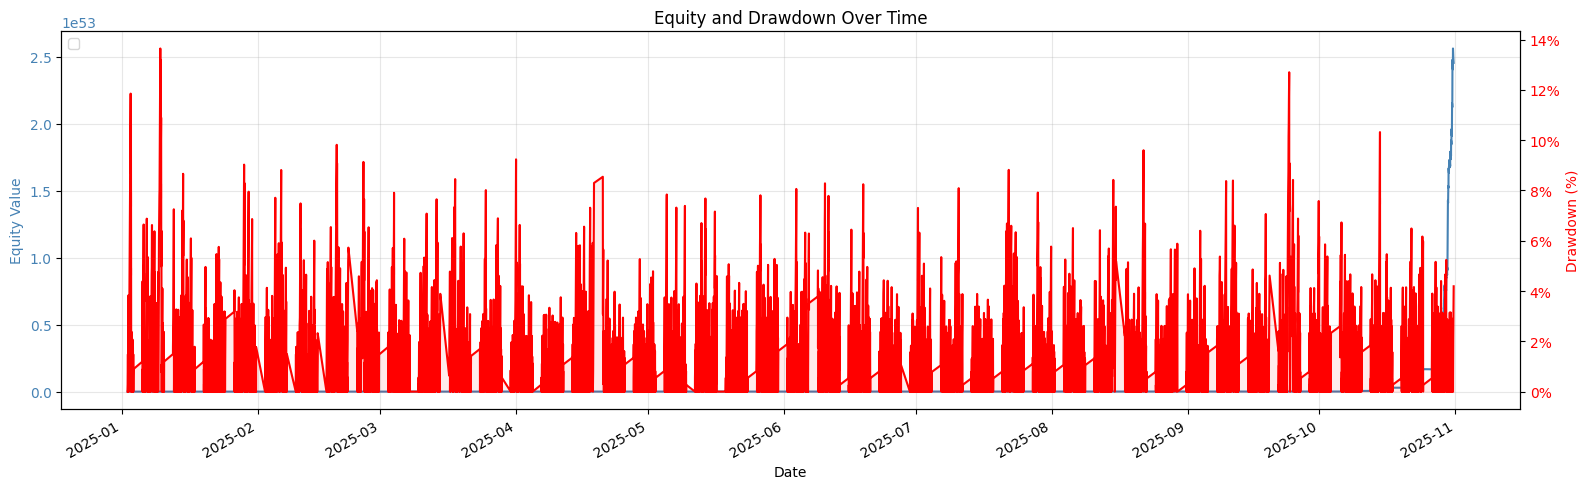

In [11]:
start_plot_date = "2025-01-01 00:00:00+00:00" #xxxxxxxxx
end_plot_date = "2025-12-01 00:00:00+00:00"

# Define the data to be plotted
plot_data_equity = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['Equity']
plot_data_drawdown = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerc']

import matplotlib.pyplot as plt

# Assumes:
#   plot_data_equity: pandas Series indexed by datetime
#   plot_data_drawdown: pandas Series (percent values, e.g. 0–30) indexed by same datetime
# If indexes differ, you can align first: common_index = plot_data_equity.index.intersection(plot_data_drawdown.index)

fig, ax1 = plt.subplots(figsize=(16, 5))

# Primary axis: Equity
line1 = plot_data_equity.plot(ax=ax1, color='steelblue', label='Equity')
ax1.set_xlabel("Date")
ax1.set_ylabel("Equity Value", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Secondary axis: Drawdown %
ax2 = ax1.twinx()
line2 = plot_data_drawdown.plot(ax=ax2, color='red', label='Drawdown %')
ax2.set_ylabel("Drawdown (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Optional: format drawdown y-axis as integer percentages
from matplotlib.ticker import PercentFormatter
ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Grid (use primary axis grid so it doesn’t duplicate)
ax1.grid(True, alpha=0.3)

# Combine legends from both axes
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Equity and Drawdown Over Time")
plt.tight_layout()

ax2.fill_between(plot_data_drawdown.index,
                plot_data_drawdown,
                0,
                color='red',
                alpha=0.08,
                label='_nolegend_')
plt.show()

/var/folders/y4/z_v90m0n50dct9ysjvtzn7r40000gp/T/ipykernel_45890/2146034527.py:39: UserWarning:

Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries



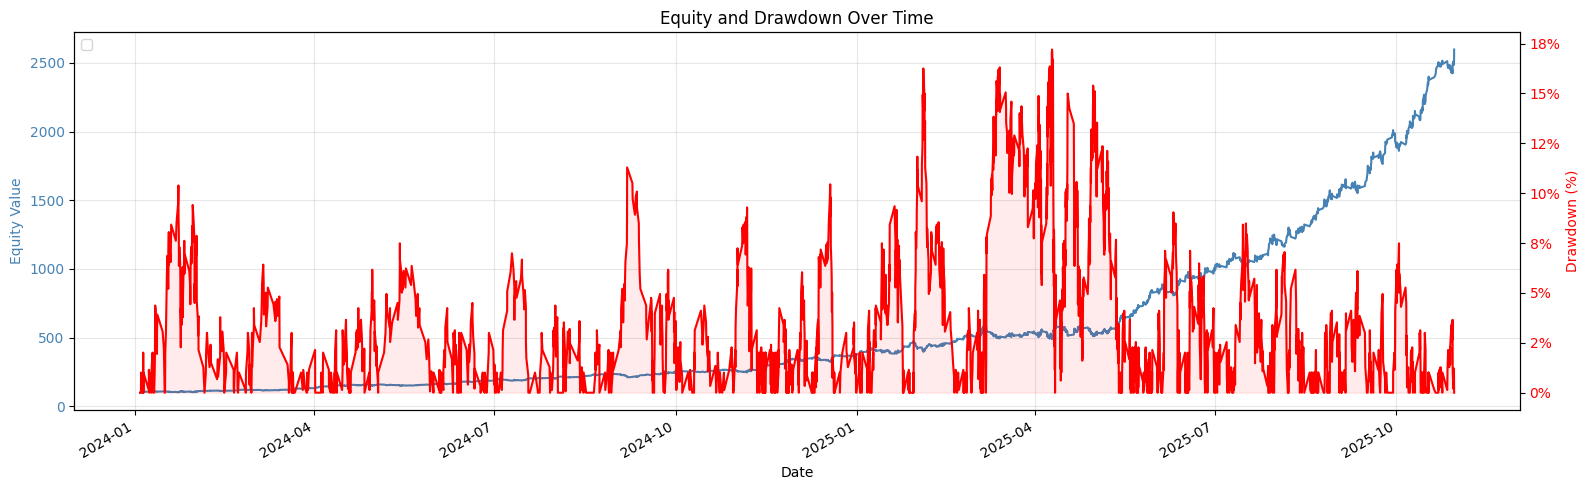

In [67]:
start_plot_date = "2023-01-01 00:00:00+00:00"
end_plot_date = "2025-12-01 00:00:00+00:00"

# Define the data to be plotted
plot_data_equity = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['Equity']
plot_data_drawdown = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerc']

import matplotlib.pyplot as plt

# Assumes:
#   plot_data_equity: pandas Series indexed by datetime
#   plot_data_drawdown: pandas Series (percent values, e.g. 0–30) indexed by same datetime
# If indexes differ, you can align first: common_index = plot_data_equity.index.intersection(plot_data_drawdown.index)

fig, ax1 = plt.subplots(figsize=(16, 5))

# Primary axis: Equity
line1 = plot_data_equity.plot(ax=ax1, color='steelblue', label='Equity')
ax1.set_xlabel("Date")
ax1.set_ylabel("Equity Value", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Secondary axis: Drawdown %
ax2 = ax1.twinx()
line2 = plot_data_drawdown.plot(ax=ax2, color='red', label='Drawdown %')
ax2.set_ylabel("Drawdown (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Optional: format drawdown y-axis as integer percentages
from matplotlib.ticker import PercentFormatter
ax2.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Grid (use primary axis grid so it doesn’t duplicate)
ax1.grid(True, alpha=0.3)

# Combine legends from both axes
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("Equity and Drawdown Over Time")
plt.tight_layout()

ax2.fill_between(plot_data_drawdown.index,
                 plot_data_drawdown,
                 0,
                 color='red',
                 alpha=0.08,
                 label='_nolegend_')
plt.show()

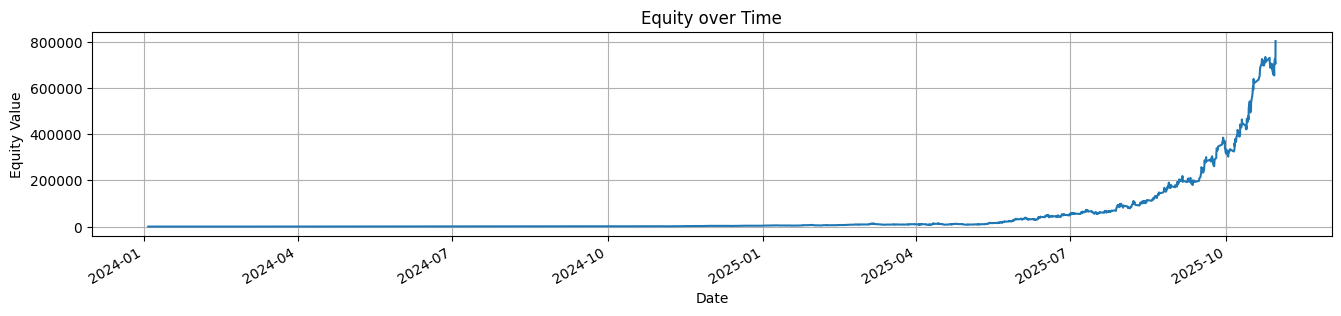

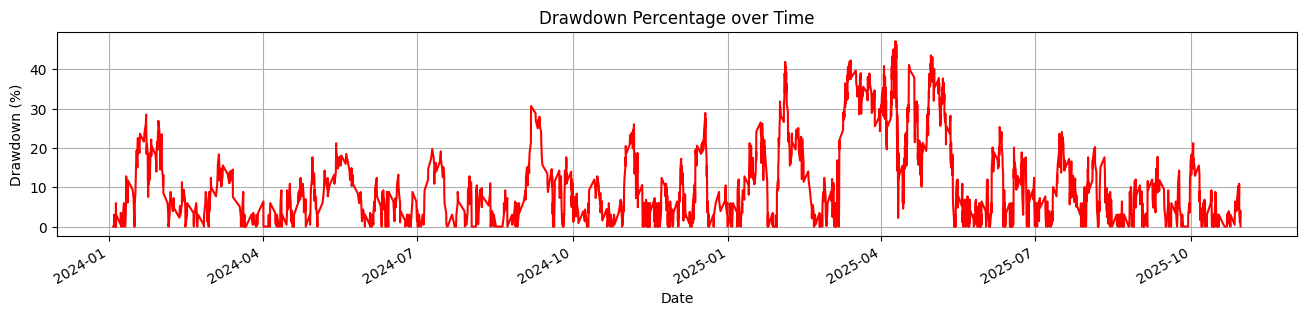

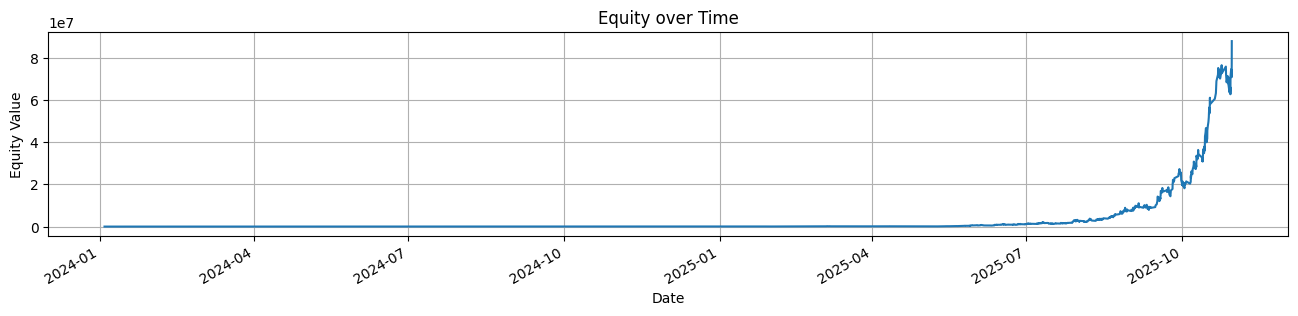

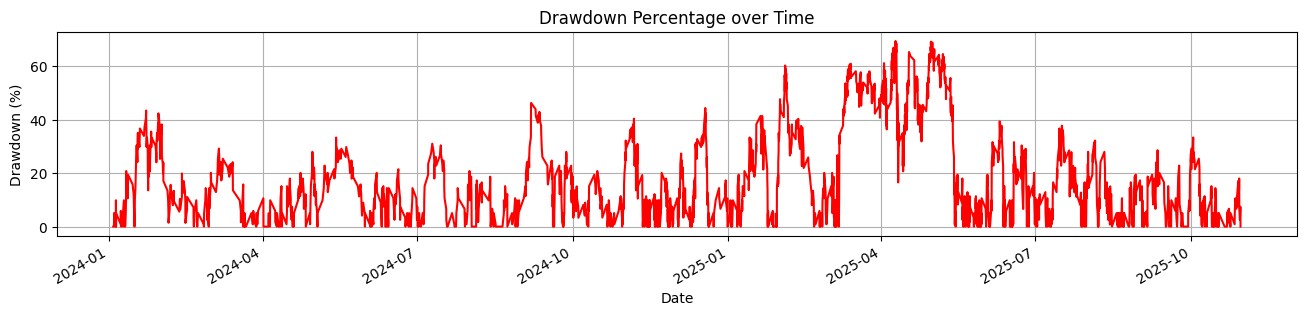

In [62]:
start_plot_date = "2023-01-01 00:00:00+00:00"
end_plot_date = "2025-12-01 00:00:00+00:00"

# Define the data to be plotted
plot_data_equity = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['Equity']
plot_data_drawdown = equity_data[(start_plot_date <= equity_data.index) & (equity_data.index <= end_plot_date)]['DrawdownPerc']

# Create the first figure and plot the 'Equity' data
plt.figure(figsize=(16, 3))  # Optional: specify figure size
plot_data_equity.plot(title='Equity over Time')
plt.xlabel("Date")
plt.ylabel("Equity Value")
plt.grid(True)

# Create the second figure and plot the 'DrawdownPerc' data
plt.figure(figsize=(16, 3))  # Optional: specify figure size
plot_data_drawdown.plot(title='Drawdown Percentage over Time', color='red')
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)

# Display the figures
plt.show()


In [63]:
0.2888 // 0.1

2.0